In [1]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
from datasets import *
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import shap
import reload_shap_plot

In [2]:
# --------------------------
# 新增方法：基于变化点检测的检测方法 (ChangePoint Detector)
# 该方法计算每个样本展平后相邻特征的差值，
# 若任一相邻差值超过预设阈值，则判定为异常
class ChangePointDetector:
    def __init__(self, feature_len, channel=1, diff_threshold=None):
        """
        feature_len: 每个样本的电压特征数量（如 n_buses-1）
        channel: 输入通道数
        diff_threshold: 电压变化阈值。如果为 None，则在 fit 时根据正常状态下相邻时间步差分自适应设定 (mean_diff + std_diff)
        """
        self.num_features = channel * feature_len
        self.diff_threshold = diff_threshold

    def fit(self, x, y=None):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        计算正常状态下沿时间轴（第一维）的电压差分的均值和标准差，
        并设定阈值：mean_diff + std_diff
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)  # shape: (n_samples, feature_dim)
        # 计算相邻时间步的差分（沿时间轴）
        diffs = np.diff(x_flat, axis=0)
        mean_diff = np.mean(np.abs(diffs))
        std_diff = np.std(np.abs(diffs))
        self.diff_threshold = mean_diff + std_diff

    def predict(self, x):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        对于每个时间步（从第二个开始），计算与前一时间步的电压差分，
        若任一时间步的最大绝对差分超过阈值，则判定为 outage，返回 1；否则返回 0。
        第一时间步由于无参考，默认返回 0。
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        diffs = np.diff(x_flat, axis=0)
        max_diffs = np.max(np.abs(diffs), axis=1)
        predictions = (max_diffs > self.diff_threshold).astype(int)
        predictions = np.insert(predictions, 0, 0)  # 第一时间步默认正常
        return predictions

    def predict_proba(self, x):
        """
        x: numpy 数组，形状为 (n_samples, channel, feature_len)
        返回: numpy 数组，形状为 (n_samples, 2)，每行分别表示正常 (0) 和 outage (1) 的概率
        对于每个时间步（从第二个开始），将最大差分与阈值的差值经过 sigmoid 映射，
        第一时间步设定为 (1, 0)。
        """
        n_samples = x.shape[0]
        x_flat = x.reshape(n_samples, -1)
        diffs = np.diff(x_flat, axis=0)
        max_diffs = np.max(np.abs(diffs), axis=1)
        diff_val = max_diffs - self.diff_threshold
        p_outage = 1 / (1 + np.exp(-diff_val))
        p_normal = 1 - p_outage
        proba = np.column_stack((p_normal, p_outage))
        proba = np.insert(proba, 0, np.array([1.0, 0.0]), axis=0)
        return proba

In [3]:
dataset = BinaryDataset('Node123_loop')
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(20))
feature_names = [f'Bus {i+1}' for i in range(1, dataset.n_buses + 1)]

In [4]:
model = ChangePointDetector(feature_len=dataset.n_buses, channel=1)

In [5]:
model.fit(train_dataset.dataset.data.numpy(), train_dataset.dataset.labels)

In [6]:
# Get predictions
y_true = test_dataset.dataset.labels[test_dataset.indices]
y_pred = model.predict(test_dataset.dataset.data[test_dataset.indices].numpy())
y_proba = model.predict_proba(test_dataset.dataset.data[test_dataset.indices])[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_proba)

# Print metrics
print(f'Accuracy: {accuracy}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'AUC: {auc}')

Accuracy: 0.4875
Recall: 0.52
F1 Score: 0.5036319612590799
AUC: 0.47295


# Explain

In [7]:
label_1_samples = []
label_0_samples = []
for data, label in train_dataset:
    if label.item() == 1:  # Filter label 1 samples
        label_1_samples.append(data)  # Convert to NumPy for SHAP
    else: 
        label_0_samples.append(data)

# Convert to NumPy array for SHAP compatibility
label_0_samples = np.array(label_0_samples)
label_1_samples = np.array(label_1_samples)

print(label_0_samples.shape)
print(label_1_samples.shape)

(800, 1, 122)
(800, 1, 122)


In [8]:
# Compute mean background from normal (label 0) samples
background_mean = label_0_samples.mean(0)  # Compute mean across samples
# background_mean = torch.tensor(np.zeros_like(background_mean)+0.1, dtype=torch.float32)  # Use zero mean as background

# Ensure at least (n_buses + 1) samples
n_buses = background_mean.shape[-1]
num_background_samples = n_buses + 1  # Ensure SHAP has enough samples

# Convert to NumPy for SHAP
background = background_mean

""" Check this line of code """
background = np.tile(background, (2, 1))  # Expand background size *2

background.shape

(2, 122)

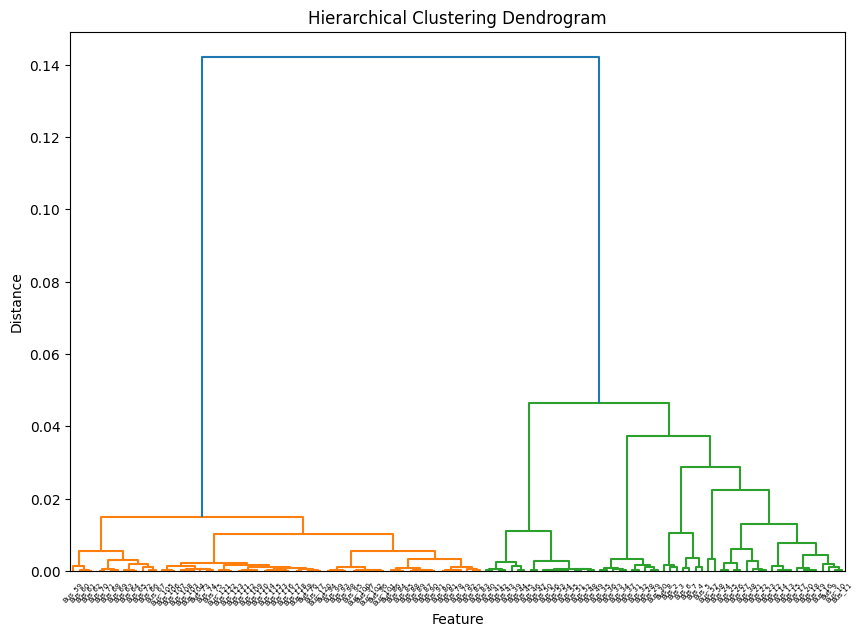

In [9]:
def get_matrix_from_data(data_normal, data_outage):
    # # Combine the two datasets
    # combined_data = pd.concat([data_normal, data_outage])
    combined_data = data_normal
    # combined_data = data_outage

    # Compute the correlation matrix
    corr_matrix = combined_data.corr()

    # Convert the correlation matrix to a distance matrix
    distance_matrix = 1 - corr_matrix

    # Perform hierarchical clustering
    Z = linkage(squareform(distance_matrix), method='average')
    return Z, corr_matrix

Z, corr_matrix = get_matrix_from_data(dataset.data_df, dataset.data_outage_df)

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=corr_matrix.columns, leaf_rotation=45)
# dendrogram(Z, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Feature')
plt.ylabel('Distance')
plt.show()

In [10]:
instance = label_1_samples[0]
instance.shape

(1, 122)

In [11]:
def model_wrapper(x):
    # Get prediction
    return model.predict_proba(x)[:, 1]

In [12]:
# Initialize SHAP Explainer
masker = shap.maskers.Partition(background)
masker.clustering = Z  # 强制使用你的 partition_tree
explainer = shap.PartitionExplainer(model_wrapper, masker, feature_names=feature_names)

In [13]:
shap_values = explainer(label_1_samples.squeeze())

PartitionExplainer explainer: 801it [00:20, 20.23it/s]                         


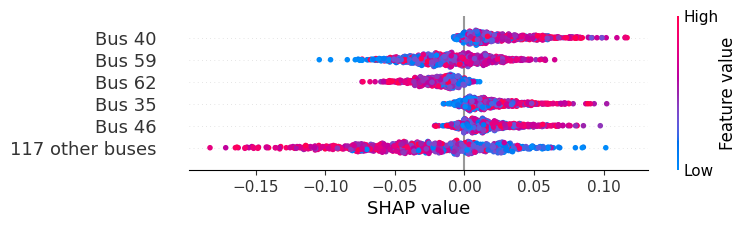

In [14]:
shap.plots.beeswarm(shap_values, max_display=6, plot_size=(7.4, 2))

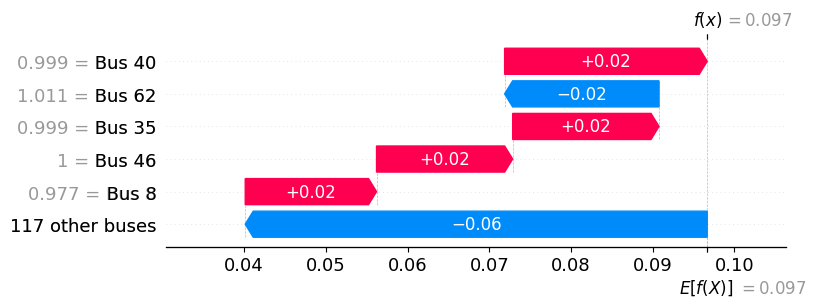

In [15]:
shap.plots.waterfall(shap_values.mean(0), max_display=6)

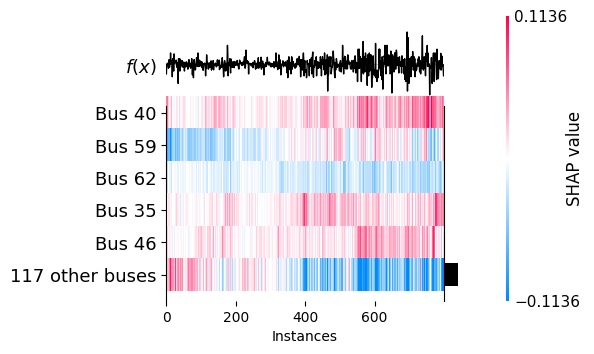

<Axes: xlabel='Instances'>

In [16]:
shap.plots.heatmap(shap_values, max_display=6)

---

In [17]:
explainer = shap.Explainer(model_wrapper, background, feature_names=feature_names)

In [18]:
shap_values = explainer(label_1_samples.squeeze())

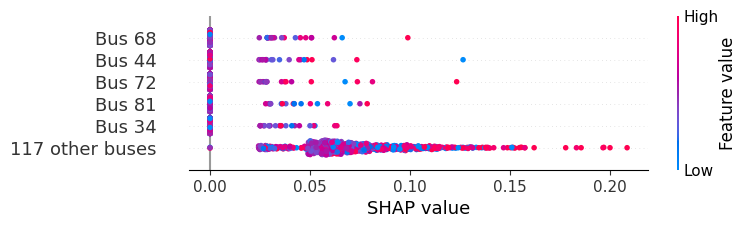

In [19]:
shap.plots.beeswarm(shap_values, max_display=6, plot_size=(7.4, 2))

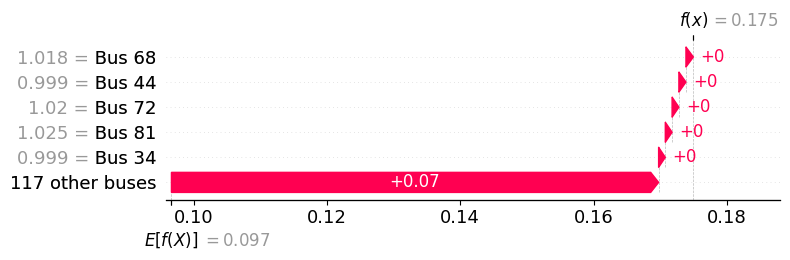

In [20]:
shap.plots.waterfall(shap_values.mean(0), show=False)
plt.tight_layout()
plt.show()

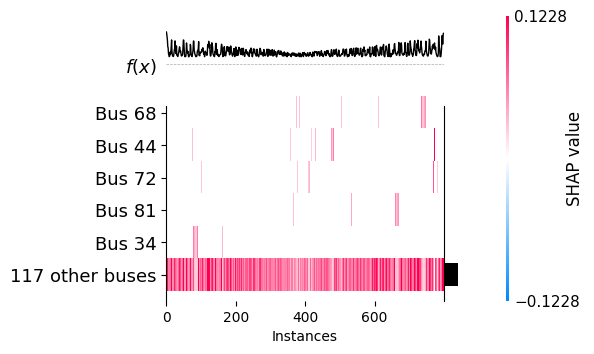

<Axes: xlabel='Instances'>

In [21]:
shap.plots.heatmap(shap_values, max_display=6)